# EDA section

### 1.Load dataset

In [2]:
from sklearn.datasets import fetch_20newsgroups

newsgroups = fetch_20newsgroups(
    subset="train",
    remove=("headers", "footers", "quotes")
)

In [3]:
import pandas as pd

df = pd.DataFrame({
    "text": newsgroups.data,
    "target": newsgroups.target
})

df["category"] = df["target"].map(
    lambda x: newsgroups.target_names[x]
)

### 2.Dataset overview

In [4]:
df.head()

,text,target,category
0,I was wondering if anyone out there could enli...,7,rec.autos
1,A fair number of brave souls who upgraded thei...,4,comp.sys.mac.hardware
2,"well folks, my mac plus finally gave up the gh...",4,comp.sys.mac.hardware
3,\nDo you have Weitek's address/phone number? ...,1,comp.graphics
4,"From article <C5owCB.n3p@world.std.com>, by to...",14,sci.space


### 3.Shape

In [5]:
print(df.shape)

(11314, 3)


### 4. Info

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11314 entries, 0 to 11313
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   text      11314 non-null  str  
 1   target    11314 non-null  int64
 2   category  11314 non-null  str  
dtypes: int64(1), str(2)
memory usage: 265.3 KB


### 5.Missing values

In [7]:
df.isnull().sum()

text        0
target      0
category    0
dtype: int64

### 6. Category distribution

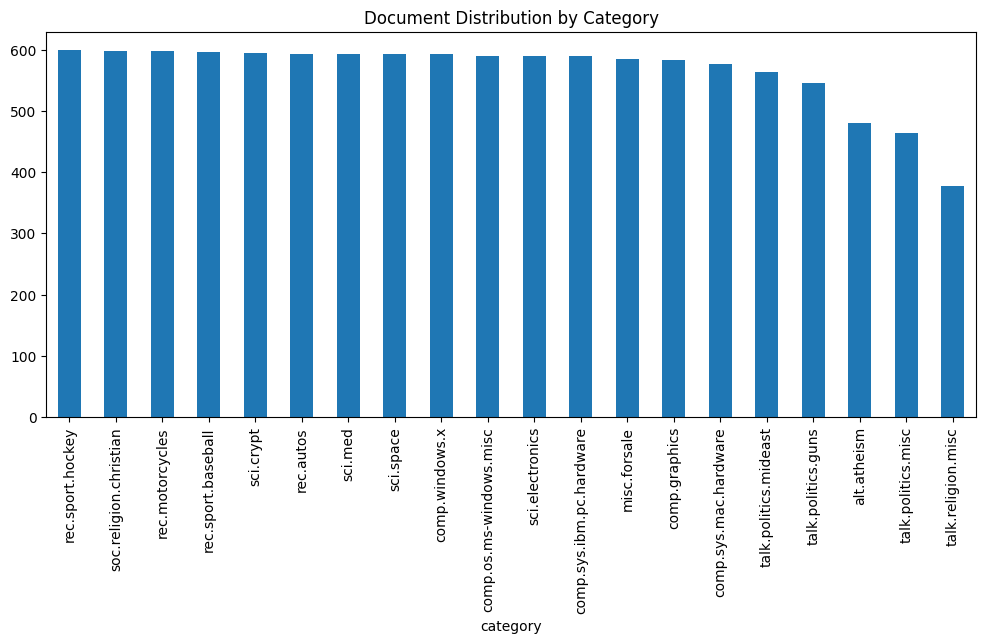

In [8]:
import matplotlib.pyplot as plt

df["category"].value_counts().plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Document Distribution by Category")
plt.show()

### 7.Document Length

In [11]:
df["length"] = df["text"].str.len()
print(df["length"])

0         475
1         530
2        1659
3          95
4         448
         ... 
11309    1782
11310     674
11311     581
11312     311
11313     321
Name: length, Length: 11314, dtype: int64


In [10]:
df["length"].describe()

count    11314.000000
mean      1218.135496
std       4038.256477
min          0.000000
25%        237.000000
50%        491.000000
75%        984.750000
max      74878.000000
Name: length, dtype: float64

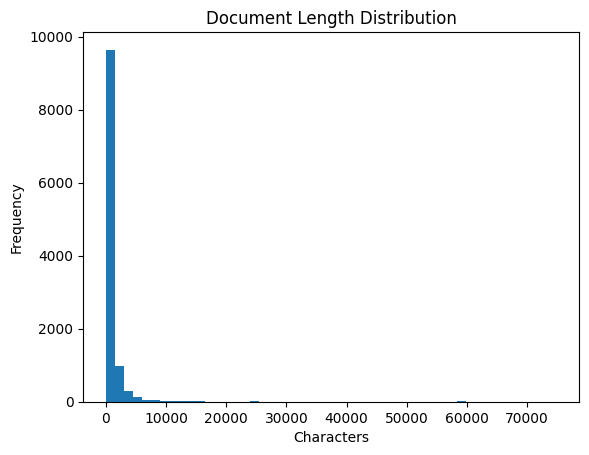

In [12]:
plt.hist(df["length"], bins=50)

plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.title("Document Length Distribution")
plt.show()

# Simple text search

### 1.Text cleaning

In [13]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)       # Remove URLs
    text = re.sub(r"[^a-z\s]", " ", text)     # Remove punctuation & numbers
    text = re.sub(r"\s+", " ", text)          # Remove extra spaces
    return text.strip()

df["clean_text"] = df["text"].apply(clean_text)

### 2.TF-IDF Vectorization 

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_df=0.95,
    min_df=2
)

tfidf_matrix = vectorizer.fit_transform(df["clean_text"])

In [15]:
print(tfidf_matrix.shape)

(11314, 33815)


### 3.View vocabulary

In [16]:
print(list(vectorizer.vocabulary_.keys())[:20])

['wondering', 'enlighten', 'car', 'saw', 'day', 'door', 'sports', 'looked', 'late', 'early', 'called', 'bricklin', 'doors', 'really', 'small', 'addition', 'bumper', 'separate', 'rest', 'body']


In [17]:
print(vectorizer.get_feature_names_out()[:20])

['aa' 'aaa' 'aaf' 'aamir' 'aamrl' 'aantal' 'aao' 'aardvark' 'aarnet'
 'aaron' 'aas' 'aau' 'aav' 'aaw' 'ab' 'abandon' 'abandoned' 'abandoning'
 'abbey' 'abbott']


### 4.Search function

In [18]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

def search(query, top_k=5):

    # Clean query
    query = clean_text(query)

    # Convert query to TF-IDF
    query_vector = vectorizer.transform([query])

    # Compute cosine similarity
    similarity = cosine_similarity(query_vector, tfidf_matrix).flatten()

    # Get top-k document indices
    top_indices = similarity.argsort()[::-1][:top_k]

    # Create results
    results = pd.DataFrame({
        "Category": df.iloc[top_indices]["category"].values,
        "Similarity": similarity[top_indices],
        "Document": df.iloc[top_indices]["text"].values
    })

    return results

### 5.Text search

In [19]:
search("computer graphics")

,Category,Similarity,Document
0,comp.graphics,0.392167,"Hello netters\n\nSorry, I don't know if this i..."
1,comp.graphics,0.381027,\nMy package is based on several articles abou...
2,comp.graphics,0.359149,"\nThis sounds wonderful, but it seems no one e..."
3,comp.graphics,0.356752,"\n\tYes, that's known as ""Bresenhams Run Lengt..."
4,comp.graphics,0.354508,\n\nPoint your gopher client at merlot.welch.j...


In [20]:
search("space shuttle")

,Category,Similarity,Document
0,sci.space,0.460399,Archive-name: space/schedule\nLast-modified: $...
1,sci.space,0.458759,This notice will be posted weekly in sci.space...
2,sci.space,0.454702,Archive-name: space/net\nLast-modified: $Date:...
3,sci.space,0.450131,"For an essay, I am writing about the space shu..."
4,sci.space,0.448843,Archive-name: space/controversy\nLast-modified...


In [21]:
queries = [
    "computer graphics",
    "space shuttle",
    "baseball",
    "medicine",
    "politics"
]

for q in queries:
    print("=" * 80)
    print(f"Query: {q}")
    print(search(q))

Query: computer graphics
        Category  Similarity  \
0  comp.graphics    0.392167   
1  comp.graphics    0.381027   
2  comp.graphics    0.359149   
3  comp.graphics    0.356752   
4  comp.graphics    0.354508   

                                            Document  
0  Hello netters\n\nSorry, I don't know if this i...  
1  \nMy package is based on several articles abou...  
2  \nThis sounds wonderful, but it seems no one e...  
3  \n\tYes, that's known as "Bresenhams Run Lengt...  
4  \n\nPoint your gopher client at merlot.welch.j...  
Query: space shuttle
    Category  Similarity                                           Document
0  sci.space    0.460399  Archive-name: space/schedule\nLast-modified: $...
1  sci.space    0.458759  This notice will be posted weekly in sci.space...
2  sci.space    0.454702  Archive-name: space/net\nLast-modified: $Date:...
3  sci.space    0.450131  For an essay, I am writing about the space shu...
4  sci.space    0.448843  Archive-name: space/contr

### 8. Result Analysis

To evaluate the performance of the search system, several queries were tested using the TF-IDF and Cosine Similarity approach.

For example, when the query **"computer graphics"** is entered, the search engine returns documents that primarily belong to the **comp.graphics** category. This indicates that the TF-IDF representation successfully captures important keywords related to the query.

Some retrieved documents may belong to other computer-related categories such as **comp.windows.x** or **comp.sys.ibm.pc.hardware**. This is expected because these categories share many technical terms with computer graphics.

Overall, the search results demonstrate that TF-IDF combined with Cosine Similarity can effectively retrieve documents containing relevant keywords. However, the ranking is mainly based on word frequency rather than semantic understanding.

## 9. Limitations of Keyword Search

Although TF-IDF with Cosine Similarity is simple and effective, it has several limitations:

- **Lack of semantic understanding:** The model matches documents based on keywords rather than the actual meaning of the text.

- **Cannot recognize synonyms:** Words with similar meanings, such as *car* and *automobile*, are treated as different terms.

- **Sensitive to exact wording:** If the query uses different words from those in the documents, relevant documents may receive low similarity scores.

- **Cannot understand context:** Ambiguous words, such as *apple*, may refer to either the fruit or the technology company, but keyword search cannot distinguish between them.

- **Ignores word order and sentence structure:** TF-IDF treats documents as collections of words and does not capture grammatical relationships or context.

### Possible Improvements

The search system could be improved by using more advanced retrieval methods, such as:

- BM25 ranking
- Word2Vec or FastText embeddings
- Sentence-BERT (SBERT)
- Dense semantic retrieval
- Hybrid search combining keyword-based and semantic search